# Clase 2 — Transformers para Lenguaje Natural (LLMs)

<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Google Colab"/></a>

> Para usarlo en Google Colab: sube este notebook a Colab o guárdalo en Drive y ábrelo desde `Archivo > Abrir notebook`.

En la Clase 1 construimos el bloque Transformer. Ahora lo ponemos a trabajar en su dominio original: el **lenguaje**. Veremos cómo apilar bloques *decoder* produce un **modelo de lenguaje de gran escala (LLM)**, cómo genera texto, cómo se preentrena y cómo se adapta.

**Objetivos.** Al terminar deberías poder:
1. Distinguir las **tres familias** de arquitecturas (decoder, encoder, encoder-decoder) y qué tareas resuelve cada una.
2. Explicar cómo un LLM convierte tareas de NLP en **predicción de la siguiente palabra**.
3. Comparar estrategias de **decoding/muestreo**: greedy, top-k, top-p y **temperatura**.
4. Describir el **preentrenamiento auto-supervisado** (teacher forcing, cross-entropy) y las **scaling laws**.
5. Adaptar un LLM con **fine-tuning** y **LoRA/PEFT**, y usarlo con **prompting**.

**Formato (≈ 3 horas):** teoría + práctica intercaladas. Bloques 🧪 son prácticos. Activa **GPU** (*Entorno de ejecución → Cambiar tipo de entorno → GPU*).

| Bloque | Tema | ~min |
|---|---|---|
| 0 | Del Transformer al LLM: tres familias | 20 |
| 1 | Tareas como predicción de palabras | 20 |
| 2 | Decoding y muestreo | 25 |
| — | *Descanso* | 10 |
| 3 | Preentrenamiento y escala | 30 |
| 4 | Fine-tuning, PEFT y LoRA | 25 |
| 5 | 🧪 Práctica: generación, temperatura, fine-tuning y few-shot | 45 |

## Bloque 0 · Del Transformer al LLM

In [ ]:
# Setup
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [ ]:
!pip install -q transformers datasets

Un **modelo de lenguaje** asigna probabilidades a secuencias de palabras y genera texto muestreando la siguiente. Los **LLMs** son la versión a gran escala: el *mismo* bloque Transformer de la Clase 1, apilado muchas veces y entrenado sobre cantidades enormes de texto. Solo se entrenan para **predecir palabras** — y de ahí emerge una sorprendente cantidad de conocimiento.

Hay **tres familias** de arquitecturas:

<img src="https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/img/m3_11_llm_arquitecturas.png" width="760">

<sub>Las tres familias: solo-decoder (GPT, Claude, Llama), solo-encoder (BERT) y encoder-decoder (T5, Whisper).</sub>

- **Solo-decoder (autoregresivos):** GPT, Claude, Llama. Predicen la siguiente palabra de **izquierda a derecha** (*causal*). Son los generadores.
- **Solo-encoder:** familia **BERT**. Predicen palabras **enmascaradas** usando el contexto de ambos lados (*Masked Language Models*). Se afinan para clasificación.
- **Encoder-decoder:** T5, Whisper. Mapean una secuencia a otra (traducción, voz→texto).

<img src="https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/img/m3_10_bert.png" width="620">

<sub>BERT: un encoder Transformer entrenado para reconstruir palabras enmascaradas (MLM).</sub>

## Bloque 1 · Muchas tareas NLP son predicción de palabras

La gran idea de los LLMs generativos: **casi cualquier tarea de NLP se puede plantear como completar texto**.

**Análisis de sentimiento** — le pedimos al modelo:
> `The sentiment of the sentence "I like Jackie Chan" is:`

y comparamos $P(\text{positive}\mid\cdot)$ vs $P(\text{negative}\mid\cdot)$.

**Pregunta-respuesta**, **resumen** (`tl;dr`), **traducción**... todo es *generación condicionada en el texto previo* (*conditional generation*). El modelo genera la **completación** dado un **prefijo**.

In [ ]:
# Demo: 'clasificar' con un modelo de lenguaje = comparar probabilidades de completación
# (idea conceptual; en la práctica se hace con logits reales del modelo)
frase = 'The sentiment of "I like Jackie Chan" is:'
opciones = {" positive": None, " negative": None}
print("Prompt:", frase)
print("El LLM elige la opción con mayor P(opción | prompt).")
print("=> No se entrena un clasificador; se REUTILIZA el modelo de lenguaje.")

## Bloque 2 · Decoding y muestreo

Elegir la palabra a generar a partir de las probabilidades del modelo se llama **decoding**. Es un balance entre **calidad** (coherente, factual) y **diversidad** (creativo, no repetitivo).

- **Greedy / argmax:** siempre la más probable. Coherente pero repetitivo, y miope.
- **Random sampling:** muestrear según $p(w)$. Muy diverso, pero la larga cola de palabras improbables genera incoherencias.
- **Top-k:** muestrear solo entre las $k$ palabras más probables (renormalizando).
- **Top-p (nucleus):** muestrear del conjunto más pequeño cuya probabilidad acumulada supera $p$. El tamaño se adapta a cada paso.
- **Temperatura:** reescalar los logits antes del softmax, $y = \text{softmax}(u/T)$.
  - $T \to 0$: la distribución se concentra en la palabra más probable (→ greedy).
  - $T > 1$: la distribución se aplana (más aleatorio, más creativo).

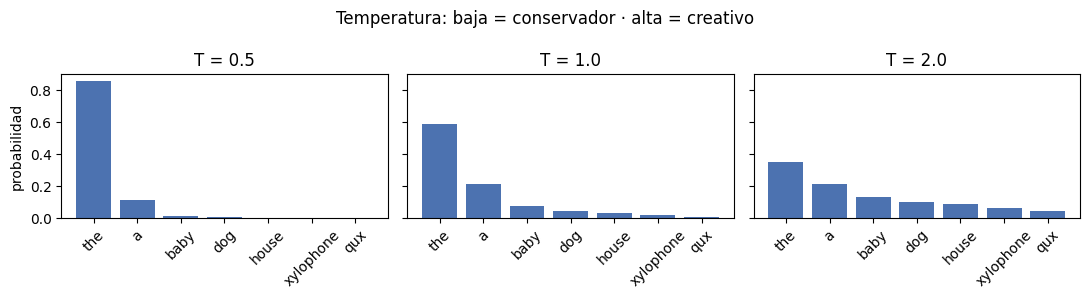

In [ ]:
# Demo: efecto de la temperatura sobre una distribución de próxima palabra
logits = torch.tensor([3.0, 2.0, 1.0, 0.5, 0.2, -0.5, -1.0])
palabras = ["the","a","baby","dog","house","xylophone","qux"]
fig, axs = plt.subplots(1, 3, figsize=(11, 3), sharey=True)
for ax, T in zip(axs, [0.5, 1.0, 2.0]):
    p = torch.softmax(logits / T, dim=0)
    ax.bar(palabras, p, color="#4C72B0"); ax.set_title(f"T = {T}")
    ax.tick_params(axis="x", rotation=45)
axs[0].set_ylabel("probabilidad")
plt.suptitle("Temperatura: baja = conservador · alta = creativo"); plt.tight_layout(); plt.show()

In [ ]:
# Demo: top-k y top-p sobre la misma distribución (T=1)
p = torch.softmax(logits, dim=0)
orden = p.argsort(descending=True)
# top-k (k=3)
k = 3; topk = orden[:k]
print("top-k=3 -> se muestrea solo entre:", [palabras[i] for i in topk])
# top-p (p=0.9)
acum, nucleo = 0.0, []
for i in orden:
    nucleo.append(palabras[i]); acum += p[i].item()
    if acum >= 0.9: break
print(f"top-p=0.9 -> núcleo (acum={acum:.2f}):", nucleo)

top-k=3 -> se muestrea solo entre: ['the', 'a', 'baby']
top-p=0.9 -> núcleo (acum=0.94): ['the', 'a', 'baby', 'dog']


## Bloque 3 · Preentrenamiento y escala

El motor de los LLMs es el **preentrenamiento auto-supervisado**: entrenar sobre muchísimo texto para **predecir la siguiente palabra**. La "etiqueta" es la propia palabra siguiente — no requiere anotación humana.

**Teacher forcing.** En entrenamiento, en cada posición el modelo ve los tokens **correctos** anteriores (no sus propias predicciones) y se le penaliza por la palabra que sigue. **Loss: cross-entropy** — queremos alta probabilidad para la palabra verdadera:

$$ L_{CE}(\hat y, y) = -\log \hat y[\,w_{t+1}\,] $$

**Los datos** vienen de la web (Common Crawl, C4, The Pile), filtrados por calidad y seguridad. Esto trae **problemas reales**: derechos de autor, consentimiento y privacidad.

In [ ]:
# Demo: cross-entropy sobre la próxima palabra (teacher forcing)
vocab = ["the","baby","is","crying","dog"]
logits = torch.tensor([2.5, 0.3, 1.0, 0.2, -0.4])   # predicción del modelo
objetivo = vocab.index("baby")                      # palabra correcta
p = torch.softmax(logits, dim=0)
loss = -torch.log(p[objetivo])
print("P(baby) =", round(p[objetivo].item(), 3), "-> loss =", round(loss.item(), 3))
print("Si el modelo diera P(baby) alta, el loss sería bajo. El entrenamiento empuja hacia allí.")

<START> El curso de Transformers es bacan <END>

<START> El curso de Transformers -> es

<START> El curso de Transformers es -> bacan

<START> El curso de Transformers es bacan -> <END>




### Scaling laws
El rendimiento de un LLM (su *loss*) mejora de forma predecible (una *power-law*) con **tres** factores: número de **parámetros** $N$, tamaño del **dataset** $D$ y **cómputo** $C$. Estas leyes permiten *predecir*, antes de entrenar, cuánto ganarás al añadir más datos o capacidad — y guiaron la construcción de los modelos gigantes actuales (GPT-3: ~175 mil millones de parámetros).

> **Eficiencia en inferencia — KV cache.** Al generar token a token, no hace falta recomputar las *keys* y *values* de todos los tokens previos: se **almacenan en caché** (KV cache) y se reutilizan. Es clave para que la generación sea rápida.

## Bloque 4 · Fine-tuning, PEFT y LoRA

Un modelo preentrenado es generalista. Para especializarlo en un dominio (medicina, leyes) o tarea, se hace **fine-tuning**: continuar el entrenamiento sobre datos nuevos.

El problema: un LLM tiene *demasiados* parámetros; afinarlos todos es caro en memoria y tiempo. La solución es **PEFT** (*Parameter-Efficient Fine-Tuning*): ajustar solo un pequeño subconjunto.

<img src="https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/img/m3_12_lora.png" width="640">

<sub>LoRA: se congela W y se aprende una actualización de bajo rango BA (r pequeño), con muy pocos parámetros.</sub>

**LoRA** (*Low-Rank Adaptation*) es el más popular. En vez de actualizar una matriz de pesos $W$ (grande), la **congela** y aprende una corrección de **bajo rango**:

$$ W + \Delta W \;\approx\; W + BA, \qquad A \in \mathbb{R}^{r\times d},\; B \in \mathbb{R}^{d\times r},\; r \ll d $$

Con $r=1$ o $2$ se entrena una fracción minúscula de parámetros y se obtiene casi el mismo resultado.

> **Riesgos.** Estos modelos también fallan: **alucinaciones** (inventan hechos), problemas de **copyright** y **privacidad**, **toxicidad** y **desinformación**. Evaluarlos y mitigarlos es parte del trabajo.

In [ ]:
# Demo: ¿cuántos parámetros ahorra LoRA?
d, r = 4096, 8
full = d*d                      # actualizar W completa
lora = d*r + r*d                # actualizar A (r x d) y B (d x r)
print(f"W completa: {full:,} parámetros por matriz")
print(f"LoRA (r={r}): {lora:,} parámetros  ->  {100*lora/full:.2f}% del total")

W completa: 16,777,216 parámetros por matriz
LoRA (r=8): 65,536 parámetros  ->  0.39% del total


## Bloque 5 · 🧪 Práctica

Tres ejercicios con modelos reales de Hugging Face: (A) generar texto y explorar el muestreo, (B) hacer fine-tuning de DistilBERT para clasificar sentimiento, y (C) *few-shot prompting*.

### A · Generación con un LLM y el efecto de la temperatura

In [ ]:
from transformers import pipeline

generador = pipeline("text-generation", model="distilgpt2", device=0 if device=="cuda" else -1)
prompt = "Deep learning is"
for temp in [0.3, 0.7, 1.2]:
    out = generador(prompt, max_new_tokens=25, do_sample=True, temperature=temp,
                    top_k=50, pad_token_id=50256)[0]["generated_text"]
    print(f"[T={temp}] {out}\n")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample', 'top_k', 'temperature', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=25) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[tran

[T=0.3] Deep learning is a very useful tool for learning about the world.
















[T=0.7] Deep learning is a powerful and powerful combination of learning and learning for a wide variety of students. The learning of learning of learning is a powerful

[T=1.2] Deep learning is part of the normal social networks that operate at one level and operate with limited resources -- something that I‹ love. People



### 🧩 Ejercicio 1
Repite la generación variando `top_k` y `top_p` (pasa `top_p=0.9, top_k=0`). ¿Cómo cambia la coherencia frente a la diversidad? Prueba también `do_sample=False` (greedy). Comenta.

In [ ]:
# @title Solución (ejemplo)
for cfg in [dict(do_sample=False), dict(do_sample=True, top_k=0, top_p=0.9),
            dict(do_sample=True, top_k=5)]:
    out = generador(prompt, max_new_tokens=25, pad_token_id=50256, **cfg)[0]["generated_text"]
    print(cfg, "\n ->", out, "\n")
print("Greedy: repetitivo. top-p alto: más diverso. top-k bajo: conservador.")

[transformers] Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=25) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample', 'top_k', 'top_p', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=25) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please

{'do_sample': False} 
 -> Deep learning is a great way to learn about the world and how to learn about the world.








 



[transformers] Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'max_new_tokens', 'top_k', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=25) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'do_sample': True, 'top_k': 0, 'top_p': 0.9} 
 -> Deep learning is a skill you can learn in your own way, not just in the classroom. It’s also a skill that you 

{'do_sample': True, 'top_k': 5} 
 -> Deep learning is a great way to learn about the world, and it is important to understand it.




In the past 

Greedy: repetitivo. top-p alto: más diverso. top-k bajo: conservador.


### B · Fine-tuning de DistilBERT (sentimiento en `rotten_tomatoes`)
Cargamos un subconjunto para agilidad y hacemos un **bucle de entrenamiento manual** (más robusto que las APIs de alto nivel entre versiones).

In [ ]:
from datasets import load_dataset
from torch.utils.data import DataLoader

ds = load_dataset("cornell-movie-review-data/rotten_tomatoes")
train_data = ds["train"].shuffle(seed=0).select(range(3000))
test_data  = ds["test"].select(range(1000))
print("train:", len(train_data), "| test:", len(test_data))

README.md:   0%|          | 0.00/7.46k [00:00<?, ?B/s]

train.parquet: reconstructing file:   0%|          |  0.00B /  699kB            

train.parquet: downloading bytes:           |  0.00B            

validation.parquet: reconstructing file:   0%|          |  0.00B / 90.0kB            

validation.parquet: downloading bytes:           |  0.00B            

...

test.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/8530 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1066 [00:00<?, ? examples/s]

train: 3000 | test: 1000


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(ckpt)

def tok_batch(batch):
    enc = tokenizer([b["text"] for b in batch], padding=True, truncation=True,
                    max_length=64, return_tensors="pt")
    enc["labels"] = torch.tensor([b["label"] for b in batch])
    return enc

bert_train = DataLoader(train_data, batch_size=32, shuffle=True, collate_fn=tok_batch)
bert_test  = DataLoader(test_data,  batch_size=64, collate_fn=tok_batch)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
model_bert = AutoModelForSequenceClassification.from_pretrained(ckpt, num_labels=2).to(device)
opt = torch.optim.AdamW(model_bert.parameters(), lr=2e-5)

def evaluar(model, loader):
    model.eval(); correct=total=0
    with torch.no_grad():
        for batch in loader:
            batch = {k:v.to(device) for k,v in batch.items()}
            logits = model(input_ids=batch["input_ids"],
                           attention_mask=batch["attention_mask"]).logits
            correct += (logits.argmax(1)==batch["labels"]).sum().item()
            total   += len(batch["labels"])
    return correct/total

print("accuracy inicial (sin entrenar):", round(evaluar(model_bert, bert_test), 3))
for epoch in range(2):                       # 2 épocas bastan al partir de un modelo preentrenado
    model_bert.train()
    for batch in bert_train:
        batch = {k:v.to(device) for k,v in batch.items()}
        opt.zero_grad()
        out = model_bert(input_ids=batch["input_ids"],
                         attention_mask=batch["attention_mask"], labels=batch["labels"])
        out.loss.backward(); opt.step()
    print(f"época {epoch+1} · accuracy test: {evaluar(model_bert, bert_test):.3f}")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


accuracy inicial (sin entrenar): 0.497
época 1 · accuracy test: 0.832
época 2 · accuracy test: 0.836


Dos épocas suelen llevar la accuracy por encima de ~0.82: el preentrenamiento sobre texto masivo le dio al modelo una enorme ventaja de partida frente a entrenar desde cero.

### B-bis · Lo mismo, pero con LoRA (PEFT)

Acabamos de afinar **todos** los ~67M de parámetros de DistilBERT. Ahora aplicamos la teoría del **Bloque 4**: en vez de eso, **congelamos** el modelo y entrenamos solo unas matrices de **bajo rango** (LoRA). Usamos la librería [`peft`](https://github.com/huggingface/peft) de Hugging Face.

La idea: inyectar $BA$ (con $r$ pequeño) en las proyecciones de atención `q_lin` y `v_lin`, dejando el resto congelado. La cabeza de clasificación (nueva para esta tarea) sí se entrena.

In [ ]:
!pip install -q peft
!pip uninstall -q -y torchao
from peft import LoraConfig, get_peft_model, TaskType

# Partimos de un DistilBERT preentrenado LIMPIO (para comparar de forma justa con el fine-tuning completo)
model_lora = AutoModelForSequenceClassification.from_pretrained(ckpt, num_labels=2)

lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_CLS,   # clasificación de secuencias
    r=8,                          # rango de la descomposición (r pequeño = pocos parámetros)
    lora_alpha=16,                # factor de escala de la actualización LoRA
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"],   # proyecciones Q y V de la atención de DistilBERT
)
model_lora = get_peft_model(model_lora, lora_cfg).to(device)

# Cuántos parámetros entrenamos realmente:
model_lora.print_trainable_parameters()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925


In [ ]:
# Entrenamiento: MISMO bucle manual que el fine-tuning completo, reutilizando evaluar(), bert_train, bert_test
opt = torch.optim.AdamW(model_lora.parameters(), lr=2e-4)   # LoRA suele tolerar un lr mayor

print("accuracy inicial (sin entrenar):", round(evaluar(model_lora, bert_test), 3))
for epoch in range(2):
    model_lora.train()
    for batch in bert_train:
        batch = {k: v.to(device) for k, v in batch.items()}
        opt.zero_grad()
        out = model_lora(input_ids=batch["input_ids"],
                         attention_mask=batch["attention_mask"], labels=batch["labels"])
        out.loss.backward(); opt.step()
    print(f"época {epoch+1} · accuracy test (LoRA): {evaluar(model_lora, bert_test):.3f}")

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


accuracy inicial (sin entrenar): 0.48
época 1 · accuracy test (LoRA): 0.813
época 2 · accuracy test (LoRA): 0.833


**Lo que acabas de ver.** LoRA entrena una **fracción minúscula** de los parámetros (típicamente < 1%) y aun así alcanza una accuracy comparable a afinar el modelo completo. Las ventajas en la práctica:

- **Memoria y velocidad:** menos gradientes que calcular y almacenar.
- **Portabilidad:** los pesos LoRA pesan unos pocos MB; puedes guardar *un adaptador por tarea* y cargarlos sobre el mismo modelo base (`model_lora.save_pretrained("adaptador_sentimiento")`).

> Para guardar/recargar solo el adaptador: `model_lora.save_pretrained(ruta)` y luego `PeftModel.from_pretrained(base, ruta)`.

### 🧩 Ejercicio (opcional)
Baja el rango a `r=2` y sube `lora_alpha` a `32`. ¿Cuántos parámetros entrenables quedan y cómo cambia la accuracy? Compáralo con el fine-tuning completo de la sección B.

### C · Few-shot prompting (in-context learning)
### 🧩 Ejercicio 2
Los LLMs generativos resuelven tareas **solo con el prompt**, sin reentrenar. Diseña un prompt *few-shot* que induzca a `distilgpt2` a clasificar sentimiento (2-3 ejemplos + una frase nueva). ¿Funciona con un modelo tan pequeño? Comenta las limitaciones.

In [ ]:
# @title Solución (ejemplo de prompt few-shot)
prompt = (
    "Review: I loved this film. Sentiment: positive\n"
    "Review: Terrible and boring. Sentiment: negative\n"
    "Review: A beautiful, moving story. Sentiment:"
)
print(generador(prompt, max_new_tokens=2, do_sample=False, pad_token_id=50256)[0]["generated_text"])
print("\nA esta técnica se le llama in-context learning: el modelo imita el patrón del prompt.")
print("distilgpt2 es diminuto, así que suele fallar. Los modelos grandes (GPT-4, Claude, Llama)")
print("hacen esto de forma fiable: es el poder de la ESCALA (scaling laws del Bloque 3).")

[transformers] Both `max_new_tokens` (=2) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Review: I loved this film. Sentiment: positive
Review: Terrible and boring. Sentiment: negative
Review: A beautiful, moving story. Sentiment: positive


A esta técnica se le llama in-context learning: el modelo imita el patrón del prompt.
distilgpt2 es diminuto, así que suele fallar. Los modelos grandes (GPT-4, Claude, Llama)
hacen esto de forma fiable: es el poder de la ESCALA (scaling laws del Bloque 3).


## Cierre

Vimos cómo el bloque Transformer se convierte en un **LLM**: las tres familias de arquitecturas, la idea de plantear tareas como **predicción de palabras**, las estrategias de **muestreo**, el **preentrenamiento** auto-supervisado con sus *scaling laws*, y la adaptación con **fine-tuning** y **LoRA**. En la práctica generaste texto, afinaste DistilBERT y probaste *few-shot prompting*.

- **Clase 3 — Visión:** el *mismo* Transformer, pero sobre **parches de imagen** → Vision Transformer (ViT).
- **Clase 4 — Multimodal:** unir lenguaje y visión (CLIP, BLIP, LLaVA) y el aprendizaje auto-supervisado.